In [1]:
import pandas as pd 
import numpy as np

In [2]:
data=pd.read_csv('telco_data.csv')

EDA & Data Preprocessing

In [3]:
data.shape

(7043, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66.0,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
data["customerID"].duplicated().sum()

np.int64(0)

In [8]:
data=data.drop(columns=["customerID"])

In [9]:
data["gender"].isna().sum()

np.int64(750)

In [10]:
data["Partner"].isna().sum()

np.int64(1000)

In [11]:
data[data["gender"].isna() & data["Partner"].isna()].isna().sum()

gender              750
SeniorCitizen         0
Partner             750
Dependents            0
tenure              750
PhoneService          0
MultipleLines         0
InternetService     750
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV         750
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges      750
TotalCharges          0
Churn                 0
dtype: int64

In [12]:
data[data["gender"].isna()][
    ["gender", "Partner", "tenure", "InternetService", "StreamingTV", "MonthlyCharges"]
].isna().sum()

gender             750
Partner            750
tenure             750
InternetService    750
StreamingTV        750
MonthlyCharges     750
dtype: int64

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5543 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [14]:
print(data[data["TotalCharges"].str.isnumeric()]["TotalCharges"].str.isnumeric().sum())
print(data[data["TotalCharges"].str.isalpha()]["TotalCharges"].str.isalpha().sum())
data.loc[data["TotalCharges"]==" ", "TotalCharges"]=np.nan
data["TotalCharges"]=data["TotalCharges"].astype(float)

324
0


In [15]:
data[data["gender"].isna()][
    ["gender", "Partner", "tenure", "InternetService", "StreamingTV", "MonthlyCharges", "TotalCharges"]
].isna().sum()

gender             750
Partner            750
tenure             750
InternetService    750
StreamingTV        750
MonthlyCharges     750
TotalCharges         0
dtype: int64

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       5543 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [17]:
data.loc[data["OnlineSecurity"]=="No internet service","InternetService"]="No"
data["InternetService"].fillna(data.loc[data["OnlineSecurity"]=="No","InternetService"].mode()[0], inplace=True)

C:\Users\eng.abo7neka\AppData\Local\Temp\ipykernel_568\148818781.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["InternetService"].fillna(data.loc[data["OnlineSecurity"]=="No","InternetService"].mode()[0], inplace=True)


In [18]:
data["InternetService"].isna().sum()

np.int64(0)

In [19]:
feat=["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for i in feat:
    data.loc[data[i]=="No internet service",i]="No"
    print(data[i].nunique())

2
2
2
2
2
2


In [20]:
data["StreamingTV"].isna().sum()

np.int64(1500)

In [21]:
data.loc[data["InternetService"]=="No", "StreamingTV"]="No"

In [22]:
data["StreamingTV"].isna().sum()

np.int64(1172)

In [23]:
data.loc[(data["StreamingTV"].isna()) & (data["InternetService"]=="DSL"), "StreamingTV"]=data.loc[(data["InternetService"]=="DSL"), "StreamingTV"].mode()[0]
data.loc[(data["StreamingTV"].isna()) & (data["InternetService"]=="Fiber optic"), "StreamingTV"]=data.loc[(data["InternetService"]=="Fiber optic"), "StreamingTV"].mode()[0]

In [24]:
data["StreamingMovies"].isna().sum()

np.int64(0)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6293 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           6043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            4543 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [26]:
feat=["InternetService","OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for i in feat:
    data.loc[data[i]=="No internet service",i]="No"
    print(i," ",data[i].unique())
    print("#"*25)

InternetService   ['DSL' 'Fiber optic' 'No']
#########################
OnlineSecurity   ['No' 'Yes']
#########################
OnlineBackup   ['Yes' 'No']
#########################
DeviceProtection   ['No' 'Yes']
#########################
TechSupport   ['No' 'Yes']
#########################
StreamingTV   ['No' 'Yes']
#########################
StreamingMovies   ['No' 'Yes']
#########################


In [27]:
data.isna().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
dtype: int64

In [28]:
data.loc[data["gender"].isna(), ["gender", "Partner", "tenure", "InternetService", "StreamingTV", "MonthlyCharges", "TotalCharges"]].isna().sum()

gender             750
Partner            750
tenure             750
InternetService      0
StreamingTV          0
MonthlyCharges     750
TotalCharges         0
dtype: int64

In [29]:
data.loc[data["gender"].isna(), "gender"]="unknown"
data.loc[data["Partner"].isna(), "Partner"]="unknown"

In [30]:
data.isna().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
dtype: int64

In [31]:
data.loc[data["TotalCharges"].isna(), [ "tenure","MonthlyCharges", "TotalCharges"]].isna().sum()

tenure             3
MonthlyCharges     2
TotalCharges      11
dtype: int64

In [32]:
data.loc[(data["tenure"].isna()==False) & (data["MonthlyCharges"].isna()==False)& (data["TotalCharges"].isna()==True), "TotalCharges"]=data["MonthlyCharges"]*data["tenure"]

In [33]:
data["TotalCharges"].isna().sum()  

np.int64(3)

In [34]:
data.loc[data["TotalCharges"].isna(), [ "tenure","MonthlyCharges", "TotalCharges"]].isna().sum()

tenure            3
MonthlyCharges    2
TotalCharges      3
dtype: int64

In [35]:
data.dropna(subset=["TotalCharges"], inplace=True)

In [36]:
data.loc[data["TotalCharges"].isna(), [ "tenure","MonthlyCharges", "TotalCharges"]].isna().sum()

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

In [37]:
data.isna().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure              2497
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1498
TotalCharges           0
Churn                  0
dtype: int64

In [38]:
data.loc[(data["tenure"].isna()==True) & (data["MonthlyCharges"].isna()==False), "tenure"]=data["TotalCharges"]//data["MonthlyCharges"]

In [39]:
data.loc[data["tenure"]==0,"tenure"].count()
data.loc[data["tenure"]==0,"tenure"]=1

In [40]:
data.isna().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure              1498
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1498
TotalCharges           0
Churn                  0
dtype: int64

In [41]:
data.loc[data["MonthlyCharges"].isna(),["tenure","MonthlyCharges"]].isna().sum()

tenure            1498
MonthlyCharges    1498
dtype: int64

In [42]:
data.loc[data["MonthlyCharges"].isna(),"MonthlyCharges"]=data.groupby(["PhoneService","InternetService","OnlineSecurity","StreamingMovies","StreamingTV","DeviceProtection","Contract"])["MonthlyCharges"].transform("median")

In [43]:
data["MonthlyCharges"].isna().sum()

np.int64(89)

In [44]:
data.loc[
    data["MonthlyCharges"].isna(),
    "MonthlyCharges"
] = data.groupby(
    ["InternetService", "Contract"]
)["MonthlyCharges"].transform("median")

In [45]:
data["MonthlyCharges"].isna().sum()

np.int64(0)

In [46]:
data.loc[(data["tenure"].isna()==True) & (data["MonthlyCharges"].isna()==False), "tenure"]=data["TotalCharges"]//data["MonthlyCharges"]

In [47]:
data.loc[data["tenure"]==0,"tenure"].count()

np.int64(125)

In [48]:
data.loc[data["tenure"]==0,"tenure"]=1

In [49]:
data.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7040 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7040 non-null   object 
 1   SeniorCitizen     7040 non-null   int64  
 2   Partner           7040 non-null   object 
 3   Dependents        7040 non-null   object 
 4   tenure            7040 non-null   float64
 5   PhoneService      7040 non-null   object 
 6   MultipleLines     7040 non-null   object 
 7   InternetService   7040 non-null   object 
 8   OnlineSecurity    7040 non-null   object 
 9   OnlineBackup      7040 non-null   object 
 10  DeviceProtection  7040 non-null   object 
 11  TechSupport       7040 non-null   object 
 12  StreamingTV       7040 non-null   object 
 13  StreamingMovies   7040 non-null   object 
 14  Contract          7040 non-null   object 
 15  PaperlessBilling  7040 non-null   object 
 16  PaymentMethod     7040 non-null   object 
 17  

In [51]:
feat1=data.columns.tolist()

In [52]:
for i in feat1:
    print(i," ",data[i].unique())
    print("#"*25)

gender   ['Female' 'Male' 'unknown']
#########################
SeniorCitizen   [0 1]
#########################
Partner   ['Yes' 'No' 'unknown']
#########################
Dependents   ['No' 'Yes']
#########################
tenure   [ 1. 34.  2. 45.  8. 22. 10. 30. 62. 13. 16. 56. 49. 24. 69. 52. 64. 18.
 12. 37. 72. 70. 27.  5. 39. 11. 51. 17. 60. 41. 14. 25. 63. 65. 74. 47.
  9. 31. 50. 53.  3. 55. 46.  7. 42. 35. 29. 68. 66. 54. 43. 36. 33. 71.
 23. 57. 59. 73. 15.  6. 21. 20.  4. 32. 40. 28. 75. 44. 61. 77. 90. 48.
 76. 67. 26. 19. 58. 38. 79. 78. 82. 83. 85. 84. 92. 81. 87. 91. 86. 95.
 80.]
#########################
PhoneService   ['No' 'Yes']
#########################
MultipleLines   ['No phone service' 'No' 'Yes']
#########################
InternetService   ['DSL' 'Fiber optic' 'No']
#########################
OnlineSecurity   ['No' 'Yes']
#########################
OnlineBackup   ['Yes' 'No']
#########################
DeviceProtection   ['No' 'Yes']
#########################
TechS

In [53]:
data.loc[data["MultipleLines"]=="No phone service","MultipleLines"]="No"

In [54]:
for i in feat1:
    print(i," ",data[i].unique())
    print("#"*25)

gender   ['Female' 'Male' 'unknown']
#########################
SeniorCitizen   [0 1]
#########################
Partner   ['Yes' 'No' 'unknown']
#########################
Dependents   ['No' 'Yes']
#########################
tenure   [ 1. 34.  2. 45.  8. 22. 10. 30. 62. 13. 16. 56. 49. 24. 69. 52. 64. 18.
 12. 37. 72. 70. 27.  5. 39. 11. 51. 17. 60. 41. 14. 25. 63. 65. 74. 47.
  9. 31. 50. 53.  3. 55. 46.  7. 42. 35. 29. 68. 66. 54. 43. 36. 33. 71.
 23. 57. 59. 73. 15.  6. 21. 20.  4. 32. 40. 28. 75. 44. 61. 77. 90. 48.
 76. 67. 26. 19. 58. 38. 79. 78. 82. 83. 85. 84. 92. 81. 87. 91. 86. 95.
 80.]
#########################
PhoneService   ['No' 'Yes']
#########################
MultipleLines   ['No' 'Yes']
#########################
InternetService   ['DSL' 'Fiber optic' 'No']
#########################
OnlineSecurity   ['No' 'Yes']
#########################
OnlineBackup   ['Yes' 'No']
#########################
DeviceProtection   ['No' 'Yes']
#########################
TechSupport   ['No' 'Yes

label encoding

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
feat2=["Dependents","PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]
for i in feat2:
    data[i] = le.fit_transform(data[i])

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7040 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7040 non-null   object 
 1   SeniorCitizen     7040 non-null   int64  
 2   Partner           7040 non-null   object 
 3   Dependents        7040 non-null   int64  
 4   tenure            7040 non-null   float64
 5   PhoneService      7040 non-null   int64  
 6   MultipleLines     7040 non-null   int64  
 7   InternetService   7040 non-null   object 
 8   OnlineSecurity    7040 non-null   int64  
 9   OnlineBackup      7040 non-null   int64  
 10  DeviceProtection  7040 non-null   int64  
 11  TechSupport       7040 non-null   int64  
 12  StreamingTV       7040 non-null   int64  
 13  StreamingMovies   7040 non-null   int64  
 14  Contract          7040 non-null   object 
 15  PaperlessBilling  7040 non-null   int64  
 16  PaymentMethod     7040 non-null   object 
 17  

One hot encoding

In [57]:
from sklearn.preprocessing import OneHotEncoder

feat3=["gender","Partner","Dependents","InternetService","PaymentMethod"]
ohe  = OneHotEncoder()
for i in feat3:
    col = np.array(data[i])
    col = col.reshape(len(col), 1)
    ohe.fit(col)
    newmatrix = ohe.transform(col).toarray()
    newmatrix = newmatrix.T
    for j, category in enumerate(ohe.categories_[0]):
        data[f"{i}_{category}"] = newmatrix[j]
for i in feat3:
    data.drop(columns=[i], inplace=True)

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7040 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7040 non-null   int64  
 1   tenure                                   7040 non-null   float64
 2   PhoneService                             7040 non-null   int64  
 3   MultipleLines                            7040 non-null   int64  
 4   OnlineSecurity                           7040 non-null   int64  
 5   OnlineBackup                             7040 non-null   int64  
 6   DeviceProtection                         7040 non-null   int64  
 7   TechSupport                              7040 non-null   int64  
 8   StreamingTV                              7040 non-null   int64  
 9   StreamingMovies                          7040 non-null   int64  
 10  Contract                                 7040 non-nul

Ordinal encoding

In [59]:
from sklearn.preprocessing import OrdinalEncoder

In [60]:
Oe = OrdinalEncoder(categories=[["Month-to-month","One year","Two year"]])
data[["Contract"]] = Oe.fit_transform(data[["Contract"]])

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7040 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7040 non-null   int64  
 1   tenure                                   7040 non-null   float64
 2   PhoneService                             7040 non-null   int64  
 3   MultipleLines                            7040 non-null   int64  
 4   OnlineSecurity                           7040 non-null   int64  
 5   OnlineBackup                             7040 non-null   int64  
 6   DeviceProtection                         7040 non-null   int64  
 7   TechSupport                              7040 non-null   int64  
 8   StreamingTV                              7040 non-null   int64  
 9   StreamingMovies                          7040 non-null   int64  
 10  Contract                                 7040 non-nul

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

Outliers

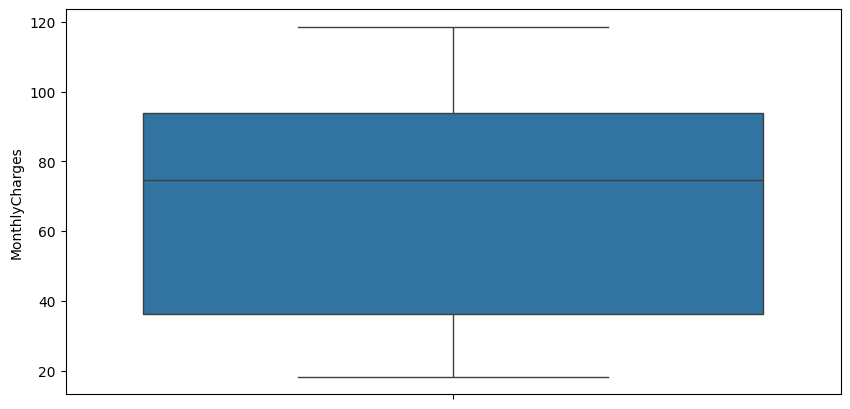

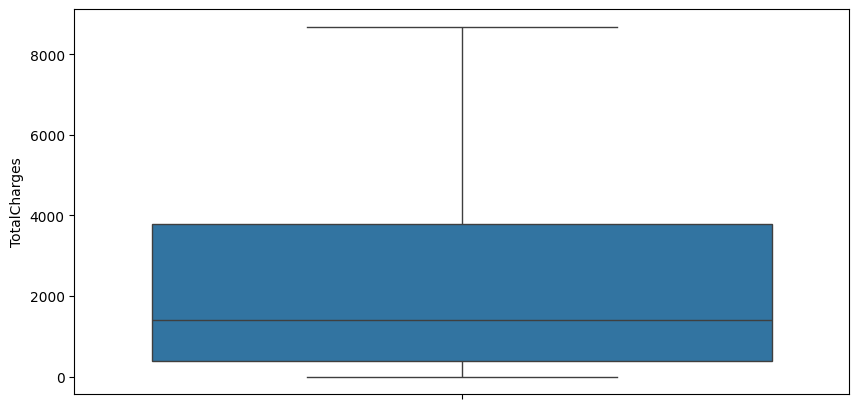

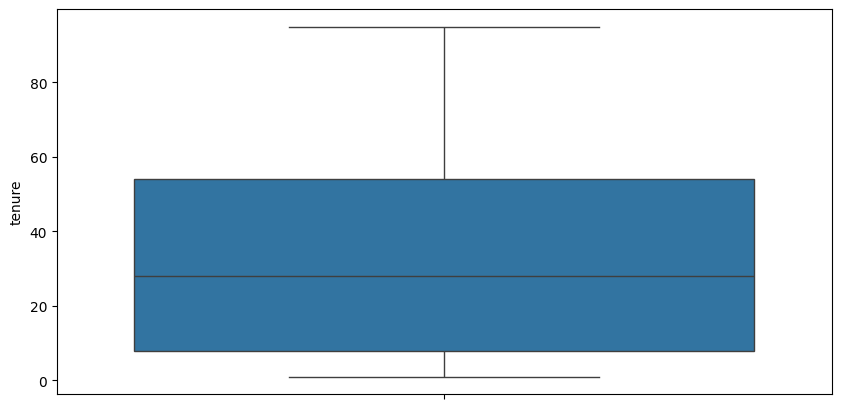

In [63]:
feat4=["MonthlyCharges","TotalCharges","tenure"]
for i in feat4:
    plt.figure(figsize=(10,5))
    sns.boxplot(data[i])

Data splitting

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
X=data.drop(columns=["Churn"])
y=data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44, shuffle =True)

The models

In [66]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics  import classification_report

Scaling

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Hyperparameter tuning & CV

We choose the recall for our evaluation because what we are interested in to know who will leave more than who will stay ||
churn=1 ||
so we need FN to be minimum

In [68]:
XGBModel = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search1 = GridSearchCV(
    estimator=XGBModel,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search1.fit(X_train, y_train)

print("Best Parameters:", grid_search1.best_params_)
print("Best CV Recall:", grid_search1.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV Recall: 0.5104038144306601


In [69]:
RFModel=RandomForestClassifier(random_state=42)
params = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search2 = GridSearchCV(
    estimator=RFModel,
    param_grid=params,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search2.fit(X_train, y_train)

print("Best Parameters:", grid_search2.best_params_)
print("Best CV Recall:", grid_search2.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Recall: 0.48152893589135193


In [70]:
param_grid = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

grid_search3 = GridSearchCV(
    GaussianNB(),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search3.fit(X_train, y_train)

print("Best Parameters:", grid_search3.best_params_)
print("Best CV Recall:", grid_search3.best_score_)

Best Parameters: {'var_smoothing': 1e-08}
Best CV Recall: 0.7448173005219985


In [71]:
KNNModel = KNeighborsClassifier()

params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search4 = GridSearchCV(
    estimator=KNNModel,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search4.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search4.best_params_)
print("Best CV Score:", grid_search4.best_score_)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}
Best CV Score: 0.5419655164621607


In [72]:
SVCModel = SVC()

params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_search5 = GridSearchCV(
    estimator=SVCModel,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search5.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search5.best_params_)
print("Best CV Score:", grid_search5.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.8240435676677288


In [73]:
LRModel = LogisticRegression(
    random_state=42,
    max_iter=1000
)

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_search6 = GridSearchCV(
    estimator=LRModel,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search6.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search6.best_params_)
print("Best CV Recall:", grid_search6.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV Recall: 0.8018778387905904


In [74]:
SGDCModel = SGDClassifier(
    random_state=42,
    max_iter=1000
)

params = {
    'loss': ['log_loss', 'hinge'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],
    'class_weight': [None, 'balanced']
}

grid_search7 = GridSearchCV(
    estimator=SGDCModel,
    param_grid=params,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search7.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search7.best_params_)
print("Best CV Recall:", grid_search7.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'alpha': 0.01, 'class_weight': 'balanced', 'loss': 'hinge', 'penalty': 'l1'}
Best CV Recall: 0.8274015320995186


Best model

In [75]:
LRModel = grid_search6.best_estimator_

ModelsScore = {}
print(f'for Model {str(LRModel).split("(")[0]}')
LRModel.fit(X_train_scaled, y_train)
print(f'Train Score is : {LRModel.score(X_train_scaled, y_train)}')
print(f'Test Score is : {LRModel.score(X_test_scaled, y_test)}')
y_pred = LRModel.predict(X_test_scaled)
ClassificationReport = classification_report(y_test,y_pred)
print('Classification Report is : \n', ClassificationReport )
print(f'Macro average Precision value is  : {ClassificationReport.split()[19]}')
print(f'Macro average Recall value is  : {ClassificationReport.split()[20]}')
print(f'Macro average F1 Score value is  : {ClassificationReport.split()[21]}')
ModelsScore[str(LRModel).split("(")[0]] = [ClassificationReport.split()[19],
                                             ClassificationReport.split()[20],ClassificationReport.split()[21]]


for Model LogisticRegression
Train Score is : 0.7354403409090909
Test Score is : 0.7407670454545454
Classification Report is : 
               precision    recall  f1-score   support

           0       0.92      0.70      0.80      1028
           1       0.51      0.84      0.64       380

    accuracy                           0.74      1408
   macro avg       0.72      0.77      0.72      1408
weighted avg       0.81      0.74      0.75      1408

Macro average Precision value is  : 0.72
Macro average Recall value is  : 0.77
Macro average F1 Score value is  : 0.72


In [76]:
SGDCModel = grid_search7.best_estimator_

ModelsScore = {}
print(f'for Model {str(SGDCModel).split("(")[0]}')
SGDCModel.fit(X_train_scaled, y_train)
print(f'Train Score is : {SGDCModel.score(X_train_scaled, y_train)}')
print(f'Test Score is : {SGDCModel.score(X_test_scaled, y_test)}')
y_pred2 = SGDCModel.predict(X_test_scaled)
ClassificationReport = classification_report(y_test,y_pred2)
print('Classification Report is : \n', ClassificationReport )
print(f'Macro average Precision value is  : {ClassificationReport.split()[19]}')
print(f'Macro average Recall value is  : {ClassificationReport.split()[20]}')
print(f'Macro average F1 Score value is  : {ClassificationReport.split()[21]}')
ModelsScore[str(SGDCModel).split("(")[0]] = [ClassificationReport.split()[19],
                                             ClassificationReport.split()[20],ClassificationReport.split()[21]]


for Model SGDClassifier
Train Score is : 0.7125355113636364
Test Score is : 0.7002840909090909
Classification Report is : 
               precision    recall  f1-score   support

           0       0.92      0.64      0.76      1028
           1       0.47      0.86      0.61       380

    accuracy                           0.70      1408
   macro avg       0.70      0.75      0.68      1408
weighted avg       0.80      0.70      0.72      1408

Macro average Precision value is  : 0.70
Macro average Recall value is  : 0.75
Macro average F1 Score value is  : 0.68


In [77]:
SVCModel = grid_search5.best_estimator_

ModelsScore = {}
print(f'for Model {str(SVCModel).split("(")[0]}')
SVCModel.fit(X_train_scaled, y_train)
print(f'Train Score is : {SVCModel.score(X_train_scaled, y_train)}')
print(f'Test Score is : {SVCModel.score(X_test_scaled, y_test)}')
y_pred3 = SVCModel.predict(X_test_scaled)
ClassificationReport = classification_report(y_test,y_pred3)
print('Classification Report is : \n', ClassificationReport )
print(f'Macro average Precision value is  : {ClassificationReport.split()[19]}')
print(f'Macro average Recall value is  : {ClassificationReport.split()[20]}')
print(f'Macro average F1 Score value is  : {ClassificationReport.split()[21]}')
ModelsScore[str(SVCModel).split("(")[0]] = [ClassificationReport.split()[19],
                                             ClassificationReport.split()[20],ClassificationReport.split()[21]]


for Model SVC
Train Score is : 0.7221235795454546
Test Score is : 0.7088068181818182
Classification Report is : 
               precision    recall  f1-score   support

           0       0.92      0.66      0.77      1028
           1       0.48      0.85      0.61       380

    accuracy                           0.71      1408
   macro avg       0.70      0.75      0.69      1408
weighted avg       0.80      0.71      0.73      1408

Macro average Precision value is  : 0.70
Macro average Recall value is  : 0.75
Macro average F1 Score value is  : 0.69


so logistic regression is better to make balance between recall and precision and f1score

In [78]:
from sklearn.metrics import confusion_matrix

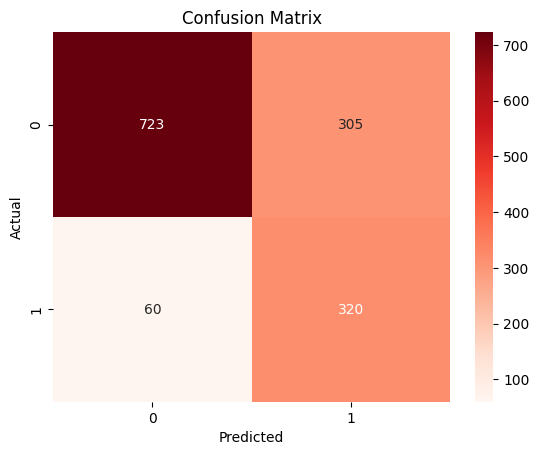

In [79]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

so after all the analysis and training we chose Logistic regression as the best model || 
Class1 Recall = 84% || Class1 Precision = 51% || Class1 F1score = 64%